In [ ]:
#@title Copyright 2025 The Earth Engine Community Authors { display-mode: "form" }
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Sentinel-2 Level 2A Benthic Habitat Mapping with Deglinting and K-Means Classification

This tutorial demonstrates how to process Sentinel-2 Level 2A Multi-Spectral Instrument (MSI) imagery for benthic habitat mapping in shallow coastal waters. The workflow includes:

1. **Sun glint removal (deglinting)** using the Hedley et al. (2005) method
2. **Depth Invariant Index (DII)** calculation using multiple band ratios (B2/B3, B3/B4, NDWI)
3. **K-Means unsupervised classification** for benthic habitat delineation

This approach is particularly useful for mapping coral reefs, seagrass beds, and other shallow water habitats where sun glint can significantly affect image quality.

## Setup and Installation

First, we'll install and import the required libraries.

In [3]:
# Install required packages
!pip install earthengine-api rasterio geopandas scikit-learn matplotlib numpy -q

In [4]:
# Import libraries
import ee
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import geopandas as gpd
from sklearn.cluster import KMeans
from google.colab import drive
import os

## Authenticate and Initialize Earth Engine

Run the following cell to initialize the Earth Engine API. The output will contain instructions on how to grant this notebook access to Earth Engine using your account.

In [8]:
# Trigger the authentication flow
ee.Authenticate()

# Initialize the library
ee.Initialize(project='ee-awr306')  # IMPORTANT: Replace 'your-project-id' with your actual Earth Engine project ID

## Mount Google Drive

Mount your Google Drive to access the Sentinel-2 imagery and shapefile.

In [10]:
# Mount Google Drive
drive.mount('/content/drive')

# Define paths to your data
# Replace 'your_folder_in_drive' with the actual path to your data within your Google Drive
drive_path = '/content/drive/MyDrive/AWR306/sentinel_benthic_data'
print(f"Data directory: {drive_path}")
print("\nContents:")
if os.path.exists(drive_path):
    print(os.listdir(drive_path))
else:
    print("Directory not found. Please ensure the folder exists in your Google Drive and update 'drive_path'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/AWR306/sentinel_benthic_data

Contents:
['T53MKP_20250408T013659_B02_10m.jp2', 'T53MKP_20250408T013659_B03_10m.jp2', 'T53MKP_20250408T013659_B04_10m.jp2', 'T53MKP_20250408T013659_B08_10m.jp2', 'aoi.cpg', 'aoi.dbf', 'aoi.prj', 'aoi.sbn', 'aoi.sbx', 'aoi.shp', 'aoi.shx', 'aoi.xml']


## Load Sentinel-2 Image and AOI Shapefile

Load the Sentinel-2 Level 2A surface reflectance image and the Area of Interest (AOI) shapefile from Google Drive.

AOI GeoJSON loaded successfully!
Original CRS: EPSG:4979
Number of features: 1
Bounds: [132.4992612  -5.9236267 132.5731415  -5.8343956]
Reprojected AOI to CRS: EPSG:4326


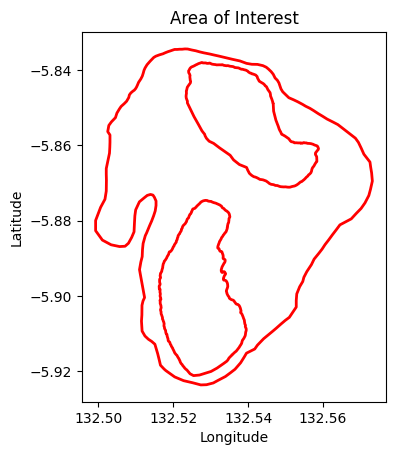

In [31]:
# Load AOI GeoJSON file
# Replace 'aoi.geojson' with your actual GeoJSON file name
geojson_path = os.path.join(drive_path, 'aoi.geojson')
aoi_gdf = gpd.read_file(geojson_path)

# Display AOI information
print("AOI GeoJSON loaded successfully!")
print(f"Original CRS: {aoi_gdf.crs}")
print(f"Number of features: {len(aoi_gdf)}")
print(f"Bounds: {aoi_gdf.total_bounds}")

# Reproject to WGS84 (EPSG:4326) for Earth Engine compatibility if needed
if aoi_gdf.crs != 'EPSG:4326':
    aoi_gdf = aoi_gdf.to_crs(epsg=4326)
    print(f"Reprojected AOI to CRS: {aoi_gdf.crs}")

# Convert to Earth Engine geometry by extracting and formatting coordinates
shapely_polygon = aoi_gdf.geometry.iloc[0]

# Helper function to convert an iterable of (x,y,z) or (x,y) tuples to a list of [x,y] lists
def format_coords_for_ee(coords_iterable):
    return [[c[0], c[1]] for c in coords_iterable]

exterior_ring_coords_formatted = format_coords_for_ee(shapely_polygon.exterior.coords)

if shapely_polygon.interiors:
    # If there are interior rings (holes), include them
    interior_ring_coords_formatted = [format_coords_for_ee(ring.coords) for ring in shapely_polygon.interiors]
    # Earth Engine expects a list where the first element is the exterior ring
    # and subsequent elements are interior rings (holes).
    # Each ring itself is a list of [lon, lat] pairs.
    all_rings_for_ee = [exterior_ring_coords_formatted] + interior_ring_coords_formatted
    aoi = ee.Geometry.Polygon(all_rings_for_ee)
else:
    # If no interior rings, just use the exterior ring, wrapped in a list
    # as ee.Geometry.Polygon expects a list of linear rings.
    aoi = ee.Geometry.Polygon([exterior_ring_coords_formatted])

# Display the AOI
aoi_gdf.plot(facecolor='none', edgecolor='red', linewidth=2)
plt.title('Area of Interest')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [23]:
# Option 1: Load Sentinel-2 from Earth Engine (recommended)
# Define date range
start_date = '2024-01-01'
end_date = '2024-12-31'

# Load Sentinel-2 Level 2A Surface Reflectance
s2_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                .filterBounds(aoi)
                .filterDate(start_date, end_date)
                .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
                .sort('CLOUDY_PIXEL_PERCENTAGE'))

# Get the least cloudy image
s2_image = s2_collection.first()

# Select visible and NIR bands
s2_image = s2_image.select(['B2', 'B3', 'B4', 'B8'])

print(f"Number of images found: {s2_collection.size().getInfo()}")
print(f"Selected image date: {ee.Date(s2_image.get('system:time_start')).format('YYYY-MM-dd').getInfo()}")

Number of images found: 4
Selected image date: 2024-10-30


## Sun Glint Removal (Deglinting)

Sun glint is specular reflection from the water surface that can obscure benthic features. We'll use the Hedley et al. (2005) deglinting method, which assumes a linear relationship between glint and NIR reflectance in deep water areas.

**Method:**
1. Identify deep water pixels (NIR sample region)
2. Calculate regression slope (b) between NIR and visible bands
3. Apply correction: `Band_deglint = Band - b × (NIR - min(NIR))`

In [24]:
def hedley_deglint(image, nir_band='B8', min_nir_percentile=1):
    """
    Apply Hedley et al. (2005) sun glint removal.

    Args:
        image: ee.Image - Sentinel-2 image
        nir_band: str - NIR band name (default 'B8')
        min_nir_percentile: float - Percentile for minimum NIR (default 1)

    Returns:
        ee.Image - Deglinted image
    """
    # Get band names (excluding NIR)
    visible_bands = ['B2', 'B3', 'B4']

    # Calculate minimum NIR value
    nir = image.select(nir_band)
    min_nir = nir.reduceRegion(
        reducer=ee.Reducer.percentile([min_nir_percentile]),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get(nir_band)

    # Calculate NIR difference
    nir_diff = nir.subtract(ee.Number(min_nir))

    # Apply deglinting to each visible band
    deglinted_bands = []

    for band in visible_bands:
        # Sample pixels to calculate regression slope
        # Using a deep water region (high NIR, assumed to be glint-affected)
        sample = image.select([band, nir_band]).sample(
            region=aoi,
            scale=10,
            numPixels=500,
            seed=42
        )

        # Calculate regression slope
        regression = sample.reduceColumns(
            reducer=ee.Reducer.linearFit(),
            selectors=[nir_band, band]
        )

        slope = ee.Number(regression.get('scale'))

        # Apply deglinting: Band_corrected = Band - slope × (NIR - min_NIR)
        deglinted = image.select(band).subtract(nir_diff.multiply(slope))
        deglinted_bands.append(deglinted.rename(band + '_deglint'))

    # Combine deglinted bands
    deglinted_image = ee.Image.cat(deglinted_bands)

    # Add original NIR band
    return deglinted_image.addBands(nir)

# Apply deglinting
s2_deglinted = hedley_deglint(s2_image)

print("Deglinting completed!")
print(f"Deglinted bands: {s2_deglinted.bandNames().getInfo()}")

Deglinting completed!
Deglinted bands: ['B2_deglint', 'B3_deglint', 'B4_deglint', 'B8']


### Visualize Original vs Deglinted Image

In [25]:
# Import folium for interactive visualization
import folium

# Define visualization parameters
vis_params_original = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.4
}

vis_params_deglint = {
    'bands': ['B4_deglint', 'B3_deglint', 'B2_deglint'],
    'min': 0,
    'max': 3000,
    'gamma': 1.4
}

# Helper function to add EE layers to folium
def add_ee_layer(self, ee_image_object, vis_params, name, show=True, opacity=1):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        show=show,
        opacity=opacity,
        overlay=True,
        control=True
    ).add_to(self)

# Add method to folium
folium.Map.add_ee_layer = add_ee_layer

# Create map centered on AOI
center = aoi.centroid(10).coordinates().reverse().getInfo()
m = folium.Map(location=center, zoom_start=12)

# Add layers
m.add_ee_layer(s2_image, vis_params_original, 'Original S2', True, 1)
m.add_ee_layer(s2_deglinted, vis_params_deglint, 'Deglinted S2', True, 1)

# Add layer control
m.add_child(folium.LayerControl())

# Display map
display(m)

## Depth Invariant Index (DII) Calculation

Depth Invariant Indices help to reduce the effect of varying water depth on substrate classification. We'll calculate several indices:

1. **DII (B2/B3)**: Blue/Green ratio - sensitive to water depth
2. **DII (B3/B4)**: Green/Red ratio - useful for shallow benthic features
3. **NDWI**: Normalized Difference Water Index - (Green - NIR) / (Green + NIR)

**Formula for band ratio DII:**
```
DII = ln(Band_i) - (ki/kj) × ln(Band_j)
```
where ki and kj are attenuation coefficients (approximated by linear regression).

In [26]:
def calculate_dii_indices(image):
    """
    Calculate Depth Invariant Indices from deglinted image.

    Args:
        image: ee.Image - Deglinted Sentinel-2 image

    Returns:
        ee.Image - Image with DII bands added
    """
    # Get deglinted bands
    b2 = image.select('B2_deglint')
    b3 = image.select('B3_deglint')
    b4 = image.select('B4_deglint')
    b8 = image.select('B8')

    # Add small constant to avoid log(0)
    epsilon = 0.0001
    b2 = b2.add(epsilon)
    b3 = b3.add(epsilon)
    b4 = b4.add(epsilon)

    # 1. DII B2/B3 (Blue/Green)
    # Simplified approach using log ratio
    dii_b2_b3 = b2.log().divide(b3.log()).rename('DII_B2_B3')

    # 2. DII B3/B4 (Green/Red)
    dii_b3_b4 = b3.log().divide(b4.log()).rename('DII_B3_B4')

    # 3. NDWI (Normalized Difference Water Index)
    ndwi = b3.subtract(b8).divide(b3.add(b8)).rename('NDWI')

    # 4. Additional useful indices
    # Simple ratio indices
    ratio_b2_b3 = b2.divide(b3).rename('Ratio_B2_B3')
    ratio_b3_b4 = b3.divide(b4).rename('Ratio_B3_B4')

    # Normalized Difference indices
    nd_b2_b3 = b2.subtract(b3).divide(b2.add(b3)).rename('ND_B2_B3')
    nd_b3_b4 = b3.subtract(b4).divide(b3.add(b4)).rename('ND_B3_B4')

    # Combine all indices
    dii_image = ee.Image.cat([
        image,
        dii_b2_b3,
        dii_b3_b4,
        ndwi,
        ratio_b2_b3,
        ratio_b3_b4,
        nd_b2_b3,
        nd_b3_b4
    ])

    return dii_image

# Calculate DII indices
s2_with_dii = calculate_dii_indices(s2_deglinted)

print("Depth Invariant Indices calculated!")
print(f"Available bands: {s2_with_dii.bandNames().getInfo()}")

Depth Invariant Indices calculated!
Available bands: ['B2_deglint', 'B3_deglint', 'B4_deglint', 'B8', 'DII_B2_B3', 'DII_B3_B4', 'NDWI', 'Ratio_B2_B3', 'Ratio_B3_B4', 'ND_B2_B3', 'ND_B3_B4']


### Visualize DII Indices

In [27]:
# Create map for DII visualization
m2 = folium.Map(location=center, zoom_start=12)

# Visualization parameters for different indices
vis_dii_b2_b3 = {
    'bands': ['DII_B2_B3'],
    'min': 0.8,
    'max': 1.2,
    'palette': ['blue', 'white', 'green']
}

vis_dii_b3_b4 = {
    'bands': ['DII_B3_B4'],
    'min': 0.8,
    'max': 1.2,
    'palette': ['green', 'white', 'red']
}

vis_ndwi = {
    'bands': ['NDWI'],
    'min': -0.5,
    'max': 0.5,
    'palette': ['brown', 'white', 'blue']
}

# Add layers
m2.add_ee_layer(s2_deglinted, vis_params_deglint, 'Deglinted RGB', True, 1)
m2.add_ee_layer(s2_with_dii, vis_dii_b2_b3, 'DII B2/B3', False, 0.7)
m2.add_ee_layer(s2_with_dii, vis_dii_b3_b4, 'DII B3/B4', False, 0.7)
m2.add_ee_layer(s2_with_dii, vis_ndwi, 'NDWI', False, 0.7)

# Add layer control
m2.add_child(folium.LayerControl())

# Display map
display(m2)

## K-Means Unsupervised Classification

We'll use K-Means clustering to classify benthic habitats based on the deglinted bands and depth invariant indices. This unsupervised approach groups pixels with similar spectral characteristics.

In [28]:
# Select bands for classification
# Using deglinted bands and DII indices
classification_bands = [
    'B2_deglint', 'B3_deglint', 'B4_deglint',
    'DII_B2_B3', 'DII_B3_B4', 'NDWI',
    'Ratio_B2_B3', 'Ratio_B3_B4'
]

classification_image = s2_with_dii.select(classification_bands)

# Set number of clusters (adjust based on expected habitat types)
n_clusters = 5  # e.g., sand, seagrass, coral, rock, deep water

# Train K-Means clusterer
training_sample = classification_image.sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=42
)

clusterer = ee.Clusterer.wekaKMeans(n_clusters).train(training_sample)

# Classify the image
classified = classification_image.cluster(clusterer)

print(f"K-Means classification completed with {n_clusters} clusters!")

K-Means classification completed with 5 clusters!


### Visualize Classification Results

In [ ]:
# Create map for classification visualization
m3 = folium.Map(location=center, zoom_start=12)

# Define color palette for clusters
# Adjust colors based on your interpretation
cluster_colors = ['001a4d', '00ff00', 'ffff00', 'ff7f00', 'ff0000']  # Example: deep blue to red

vis_classified = {
    'min': 0,
    'max': n_clusters - 1,
    'palette': cluster_colors
}

# Add layers
m3.add_ee_layer(s2_deglinted, vis_params_deglint, 'Deglinted RGB', True, 0.7)
m3.add_ee_layer(classified, vis_classified, 'K-Means Classification', True, 0.6)

# Add layer control
m3.add_child(folium.LayerControl())

# Display map
display(m3)

print("\nLegend (approximate - verify with ground truth):")
print("Cluster 0: Deep water / Dark substrate")
print("Cluster 1: Seagrass / Dense vegetation")
print("Cluster 2: Sand / Bright substrate")
print("Cluster 3: Mixed substrate")
print("Cluster 4: Coral / Reef structure")

## Export Results

Export the classification results and processed images to Google Drive for further analysis.

In [34]:
# Export classified image
export_task_classified = ee.batch.Export.image.toDrive(
    image=classified,
    description='sentinel2_benthic_classification',
    folder='sentinel_benthic_results',
    region=aoi,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e9
)

export_task_classified.start()
print("Classification export started!")
print(f"Task ID: {export_task_classified.id}")

# Export deglinted RGB composite
export_task_deglint = ee.batch.Export.image.toDrive(
    image=s2_deglinted.select(['B4_deglint', 'B3_deglint', 'B2_deglint']),
    description='sentinel2_deglinted_rgb',
    folder='sentinel_benthic_results',
    region=aoi,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e9
)

export_task_deglint.start()
print("Deglinted RGB export started!")
print(f"Task ID: {export_task_deglint.id}")

# Export DII indices
export_task_dii = ee.batch.Export.image.toDrive(
    image=s2_with_dii.select(['DII_B2_B3', 'DII_B3_B4', 'NDWI']),
    description='sentinel2_dii_indices',
    folder='sentinel_benthic_results',
    region=aoi,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e9
)

export_task_dii.start()
print("DII indices export started!")
print(f"Task ID: {export_task_dii.id}")

print("\nCheck your Earth Engine Tasks tab to monitor export progress.")
print("Results will be saved to Google Drive in the 'sentinel_benthic_results' folder.")

Classification export started!
Task ID: PI3S476WDNNTJ352E74LVUUG
Deglinted RGB export started!
Task ID: EAEB4ZJLGJRRNA52JIV4J2SF
DII indices export started!
Task ID: XFBI4AXFBATVEYVTIAT2CFEL

Check your Earth Engine Tasks tab to monitor export progress.
Results will be saved to Google Drive in the 'sentinel_benthic_results' folder.


## Classification Analysis

Calculate area statistics for each classified habitat type.


Area by habitat class:
Class 0: 189.71 hectares (1897117 m²)
Class 1: 216.50 hectares (2165009 m²)
Class 2: 927.65 hectares (9276469 m²)
Class 3: 1101.00 hectares (11009955 m²)
Class 4: 582.30 hectares (5822972 m²)
Total area: 3017.15 hectares


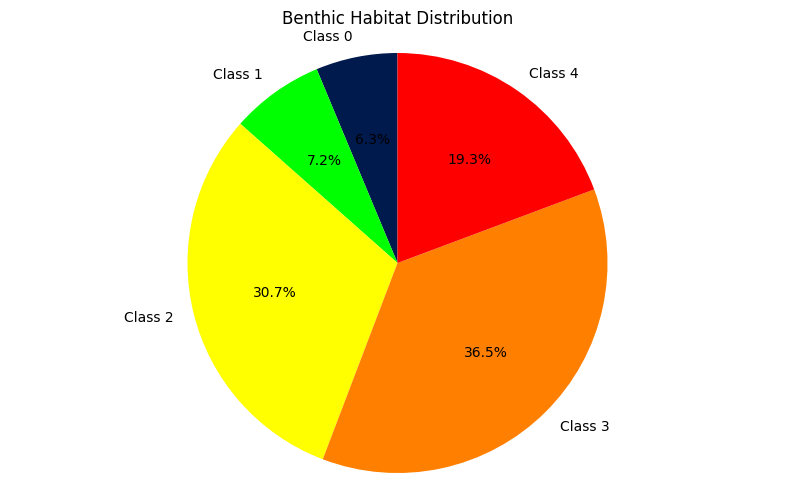

In [41]:
# Calculate area for each class
pixel_area = ee.Image.pixelArea()

# Calculate area by class
# Combine the pixel area image with the classified image.
# Now, pixel_area (band 0) will be summed, and classified (band 1) will be used for grouping.
class_areas = pixel_area.addBands(classified).reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1, # Group by the second band (classified clusters, now at index 1)
        groupName='class'
    ),
    geometry=aoi,
    scale=10,
    maxPixels=1e9,
    tileScale=16 # Add tileScale for potentially large computations
)

# Extract and display results
area_info = class_areas.getInfo()
print("\nArea by habitat class:")
print("=" * 50)

total_area = 0
# The result will be a list of dictionaries, one for each group (class)
if 'groups' not in area_info or not area_info['groups']:
    print("No class areas found. Check if AOI overlaps with classified image or if classification produced results.")
else:
    # Convert list of dicts to a single dict for easier sorting/access
    class_areas_dict = {item['class']: item['sum'] for item in area_info['groups']}
    sorted_class_ids = sorted(class_areas_dict.keys(), key=int)

    for class_id in sorted_class_ids:
        area_m2 = class_areas_dict[class_id]
        area_ha = area_m2 / 10000
        total_area += area_ha
        print(f"Class {class_id}: {area_ha:.2f} hectares ({area_m2:.0f} m²)")

    print("=" * 50)
    print(f"Total area: {total_area:.2f} hectares")

    # Create pie chart
    import matplotlib.pyplot as plt

    classes_for_chart = [f'Class {c}' for c in sorted_class_ids]
    areas_for_chart = [class_areas_dict[c] / 10000 for c in sorted_class_ids]

    plt.figure(figsize=(10, 6))
    plt.pie(areas_for_chart, labels=classes_for_chart, autopct='%1.1f%%', startangle=90, colors=['#001a4d', '#00ff00', '#ffff00', '#ff7f00', '#ff0000'])
    plt.title('Benthic Habitat Distribution')
    plt.axis('equal')
    plt.show()

## Summary

This notebook demonstrated a complete workflow for benthic habitat mapping using Sentinel-2 Level 2A imagery:

1. ✅ **Data loading**: Loaded Sentinel-2 imagery and AOI from Google Drive
2. ✅ **Deglinting**: Applied Hedley et al. (2005) sun glint removal
3. ✅ **DII calculation**: Computed multiple depth invariant indices
4. ✅ **Classification**: Performed K-Means unsupervised classification
5. ✅ **Analysis**: Calculated habitat area statistics
6. ✅ **Export**: Saved results to Google Drive

### Next Steps

- **Ground-truthing**: Validate classification results with field observations or high-resolution imagery
- **Refinement**: Adjust number of clusters and classification bands based on validation
- **Temporal analysis**: Apply workflow to multiple dates to monitor habitat changes
- **Supervised classification**: Use training data to perform supervised classification for improved accuracy

### References

- Hedley, J. D., Harborne, A. R., & Mumby, P. J. (2005). Simple and robust removal of sun glint for mapping shallow‐water benthos. *International Journal of Remote Sensing*, 26(10), 2107-2112.
- Lyzenga, D. R. (1978). Passive remote sensing techniques for mapping water depth and bottom features. *Applied Optics*, 17(3), 379-383.
- Roelfsema, C., et al. (2018). Coral reef habitat mapping: A combination of object-based image analysis and ecological modelling. *Remote Sensing of Environment*, 208, 27-41.